In [26]:
import librosa 
import numpy as np 
import sys 

sys.path.append('../')
import yaml
from corpus.jsinV3DataLoader_precombined import jsinV3_precombined
import src.audio_transforms as at

%matplotlib inline 
import matplotlib.pyplot as plt

In [14]:
config_path = '../config/attentional_cue/attn_cue_lr_1e-4_bs_64_constrain_slope.yml'

config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [77]:
dataset = jsinV3_precombined(**config['data']['corpus'],
                               train=True,
                               )

In [78]:
len(dataset)

16812

In [21]:
signal, target = dataset[0]

In [22]:
signal.shape

(40000,)

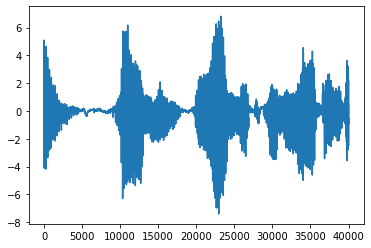

In [27]:
plt.plot(signal)

In [43]:
f0, voiced_flag, voiced_probs = librosa.pyin(signal,
                                             sr=20000,
                                             fmin=librosa.note_to_hz('C2'),
                                             fmax=librosa.note_to_hz('C7'))

times = librosa.times_like(f0)

In [65]:
librosa.yin(signal,
         sr=20000,
         fmin=librosa.note_to_hz('C2'),
         fmax=librosa.note_to_hz('C7'))


array([2222.22222222, 2222.22222222,  125.00376434,  126.12263276,
        126.27740772,  126.5467459 ,  363.59765523,  364.47721345,
        125.60884501,  487.66189228,  485.16643058, 1287.28804984,
       1669.27719811, 1670.0764723 ,  942.78799905,  957.50333733,
        980.01837674,  706.93354851,  902.97457182,  887.22306594,
        179.91818463,  586.95119188,  905.91379539,   67.27595611,
        255.79125645,  509.88852332,  155.60966711,  147.95305051,
        152.20567968,  685.08511068,  581.26389145,  563.36321831,
        153.72558481,  146.45764204,  131.08263191,  120.3841048 ,
        117.15836535,  114.92625152,  108.23334264, 2222.22222222,
       2222.22222222,  125.83630597,  123.87294192,  119.4498235 ,
        114.41613195,  113.50650476,  112.68680545,  109.49777734,
        105.56872197,  102.08219526,  100.69770551,   91.94764708,
       2222.22222222,   84.77505213,  133.73632512,  134.46527334,
        136.9455563 ,  139.8303888 , 2047.92074935,  115.69555

In [66]:
f0

array([         nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan, 125.62905732, 124.18608453, 119.26495573,
       114.53883678, 113.22324603, 112.57112812, 109.36644662,
       105.64102396, 102.04250286, 100.87044475,  91.96585291,
                nan,          nan, 133.8703865 , 134.64588976,
       136.99945846, 140.20166901,          nan,          nan,
                nan,          nan,          nan,       

In [51]:
import librosa.display


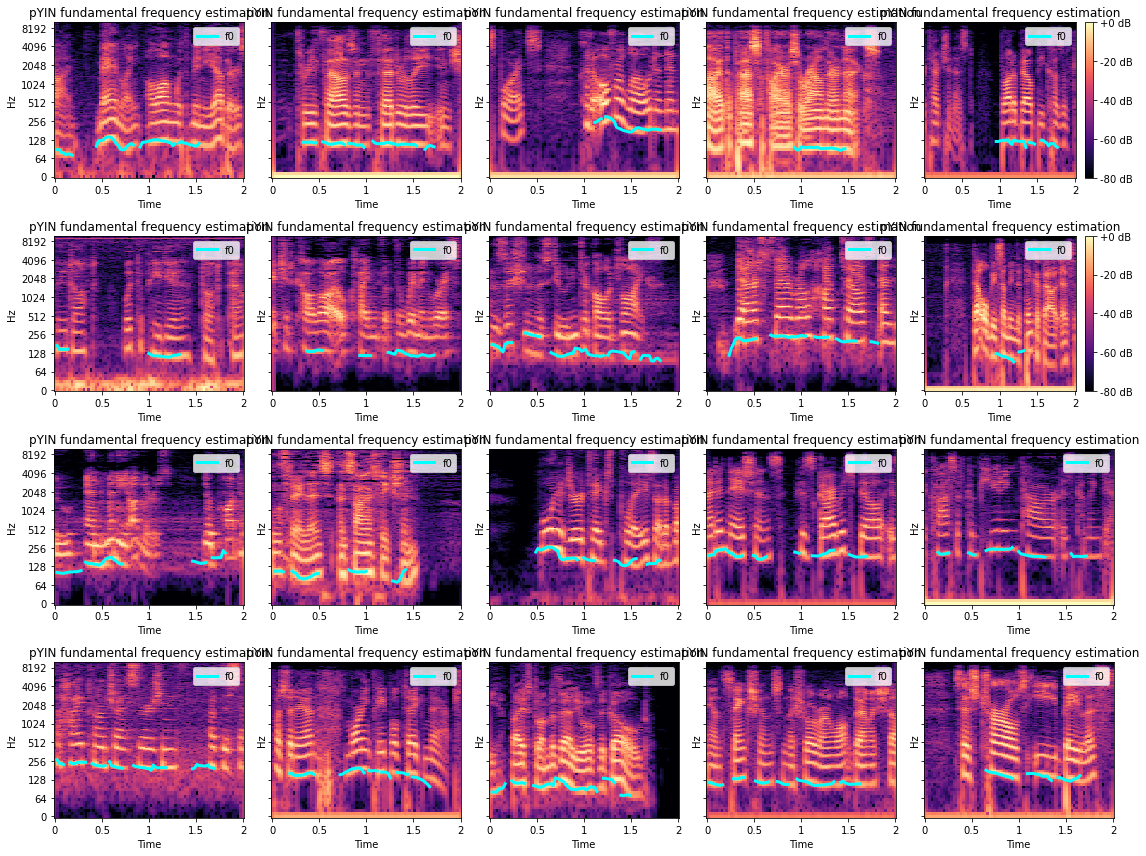

In [76]:

fig, ax = plt.subplots(4,5, figsize=(16,12), sharey=True)
ax = ax.ravel()


for ix in range(20):
    signal, target = dataset[ix]
    f0, voiced_flag, voiced_probs = librosa.pyin(signal,
                                             sr=20000,
                                             
                                             fmin=librosa.note_to_hz('C2'),
                                             fmax=librosa.note_to_hz('C7'))
    times = librosa.times_like(f0)
    
    
    D = librosa.amplitude_to_db(np.abs(librosa.stft(signal)), ref=np.max)
    
    img = librosa.display.specshow(D,sr=20000, x_axis='time', y_axis='log', ax=ax[ix])
    ax[ix].set(title='pYIN fundamental frequency estimation')
    if ix == 4 or ix == 9:
        fig.colorbar(img, ax=ax[ix], format="%+2.f dB")
    ax[ix].plot(times, f0, label='f0', color='cyan', linewidth=3)
    ax[ix].legend(loc='upper right')
    
plt.tight_layout()

In [70]:
signal, target = dataset[15]

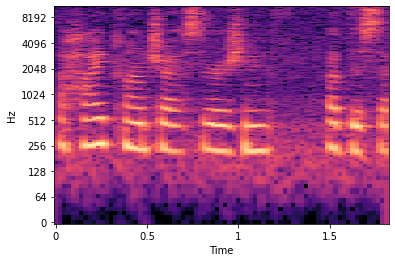

In [71]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(signal)), ref=np.max)

img = librosa.display.specshow(D, x_axis='time', y_axis='log')


In [72]:
from IPython.display import Audio
Audio(signal, rate=20000)

## Reference for generating full set of f0 traces

In [ ]:
import numpy as np 
from corpus.jsinV3DataLoader_precombined import jsinV3_precombined
import os 
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import librosa

data_path = '/om2/user/msaddler/projects/ibmHearingAid/assets/data/datasets/JSIN_v3.00/nStim_20000/2000ms/rms_0.1/noiseSNR_-10_10/stimSR_20000/reverb_none/noise_all/JSIN_all_v3/subsets/'
dataset = jsinV3_precombined(root=data_path, train=False)


def get_f0(data_ix, dataset=dataset):
    signal, target = dataset[data_ix]
    f0, voiced_flag, voiced_probs = librosa.pyin(signal,
                                             sr=20000,
                                             fmin=75,
                                             fmax=450)
    return f0 
    
    
labels = Parallel(n_jobs=40)(
            delayed(get_f0)(ix) for ix in tqdm(range(len(dataset)), total=len(dataset)))


all_labels = np.array(labels)
np.save('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/jsinV3_val_set_run_000_traces.npy', all_labels)



In [95]:
val_f0s = np.load('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/jsinV3_val_set_run_000_traces.npy')

In [88]:
import seaborn as sns

In [98]:
np.nanmin(val_f0s)

75.0

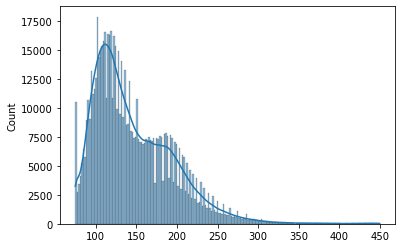

In [106]:
hst = sns.histplot(val_f0s.flatten(), bins=200, kde=True)

In [105]:
np.nanmax(val_f0s)

449.4921230630045

In [110]:
lines = hst.get_lines()[0]

In [123]:
f0s = lines.get_xdata()
kde_trace = lines.get_ydata()

In [129]:
from scipy.signal import find_peaks, find_peaks_cwt


In [140]:
# use short window wavelet to find means in data for male & female voices
f0s[find_peaks_cwt(kde_trace, np.arange(1,10))][:2]

array([108.87365937, 191.67593784])